Found 3002 images belonging to 2 classes.
Found 3003 images belonging to 2 classes.
Class mapping: {'Fake': 0, 'Real': 1}
🚀 Training model...
Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.7688 - loss: 0.4862 - val_accuracy: 0.8242 - val_loss: 0.4220
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step - accuracy: 0.8701 - loss: 0.3377 - val_accuracy: 0.8282 - val_loss: 0.3902
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 157ms/step - accuracy: 0.8837 - loss: 0.2810 - val_accuracy: 0.8162 - val_loss: 0.4144
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 159ms/step - accuracy: 0.8981 - loss: 0.2537 - val_accuracy: 0.8202 - val_loss: 0.4364
Epoch 5/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.9037 - loss: 0.2246 - val_accuracy: 0.8385 - val_loss: 0.4070


✅ Model trained and saved as deepfake_detection_model.h5

🧠 Prediction: Fake (Score: 0.0034)


c:\Users\sivam\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_image']]
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


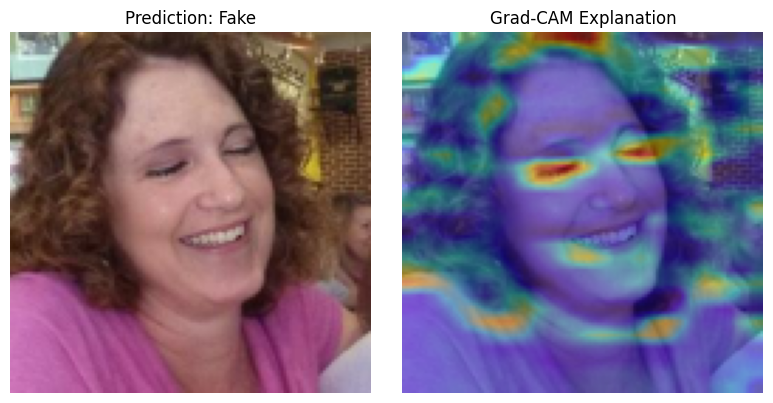

👋 Exiting program.


In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras import layers, models, Input
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tkinter as tk
from tkinter import filedialog
import os

# ---------------------------------------------------
# CONFIG
# ---------------------------------------------------
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 5
DATASET_PATH = r"C:/Users/sivam/Downloads/Dataset"  # 🔥 change path if needed
MODEL_PATH = "deepfake_detection_model.h5"

# ---------------------------------------------------
# DATA LOADING
# ---------------------------------------------------
train_dir = os.path.join(DATASET_PATH, "Train")
val_dir = os.path.join(DATASET_PATH, "Validation")

train_datagen = ImageDataGenerator(rescale=1.0 / 255)
val_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
)

# ✅ Check mapping
print("Class mapping:", train_generator.class_indices)

# ---------------------------------------------------
# MODEL DEFINITION (functional – Grad-CAM friendly)
# ---------------------------------------------------
inputs = Input(shape=(128, 128, 3), name="input_image")

x = layers.Conv2D(32, (3, 3), activation="relu", name="conv1")(inputs)
x = layers.MaxPooling2D(2, 2, name="pool1")(x)
x = layers.Conv2D(64, (3, 3), activation="relu", name="conv2")(x)
x = layers.MaxPooling2D(2, 2, name="pool2")(x)
x = layers.Conv2D(128, (3, 3), activation="relu", name="conv3")(x)
x = layers.MaxPooling2D(2, 2, name="pool3")(x)
x = layers.Flatten(name="flatten")(x)
x = layers.Dense(128, activation="relu", name="dense1")(x)
x = layers.Dropout(0.5, name="dropout")(x)
outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

model = models.Model(inputs, outputs, name="DeepFakeCNN")
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# ---------------------------------------------------
# TRAIN OR LOAD MODEL
# ---------------------------------------------------
if not os.path.exists(MODEL_PATH):
    print("🚀 Training model...")
    model.fit(train_generator, epochs=EPOCHS, validation_data=val_generator)
    model.save(MODEL_PATH)
    print(f"✅ Model trained and saved as {MODEL_PATH}")
else:
    print("📦 Loading existing model...")
    model = tf.keras.models.load_model(MODEL_PATH)
    print("✅ Model loaded successfully!")

# ---------------------------------------------------
# FUNCTION TO PICK IMAGE (works inside VS Code)
# ---------------------------------------------------
def pick_image():
    root = tk.Tk()
    root.withdraw()
    root.attributes("-topmost", True)  # bring to front
    file_path = filedialog.askopenfilename(
        title="Select an image to test",
        filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp *.tiff")],
    )
    root.destroy()
    return file_path

# ---------------------------------------------------
# PREDICT + GRAD-CAM
# ---------------------------------------------------
def predict_and_explain(img_path):
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    preds = model.predict(img_array, verbose=0)
    pred_value = float(preds.squeeze())

    # ✅ FIXED: Corrected prediction logic
    result = "Real" if pred_value > 0.5 else "Fake"

    print(f"\n🧠 Prediction: {result} (Score: {pred_value:.4f})")

    # Grad-CAM
    last_conv = model.get_layer("conv3")
    grad_model = tf.keras.models.Model(
        [model.inputs], [last_conv.output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, prediction = grad_model(img_array)
        loss = prediction[:, 0]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_out), axis=-1)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    heatmap = cv2.resize(np.array(heatmap), IMG_SIZE)
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay
    original = cv2.imread(img_path)
    original = cv2.resize(original, IMG_SIZE)
    overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title(f"Prediction: {result}")
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM Explanation")
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------
# MAIN LOOP
# ---------------------------------------------------
while True:
    path = pick_image()
    if not path:
        print("👋 No file selected. Exiting.")
        break
    predict_and_explain(path)
    again = input("\n🔁 Test another image? (y/n): ").strip().lower()
    if again != "y":
        print("👋 Exiting program.")
        break

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras import layers, models, Input
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tkinter as tk
from tkinter import filedialog, Label, Button
from PIL import Image, ImageTk
import os

# ---------------------------------------------------
# CONFIG
# ---------------------------------------------------
IMG_SIZE = (128, 128)
DATASET_PATH = r"C:/Users/sivam/Downloads/Dataset"
MODEL_PATH = "deepfake_detection_model.h5"

# ---------------------------------------------------
# LOAD MODEL
# ---------------------------------------------------
print("📦 Loading model...")
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model loaded successfully!")

# ---------------------------------------------------
# GRAD-CAM FUNCTION
# ---------------------------------------------------
def get_gradcam_heatmap(img_array, model, last_conv_layer_name="conv3"):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8
    return np.uint8(255 * heatmap)

# ---------------------------------------------------
# PREDICT + EXPLAIN FUNCTION
# ---------------------------------------------------
def predict_and_explain(img_path, label_result, label_explain, panel_heatmap):
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    preds = model.predict(img_array, verbose=0)
    pred_value = float(preds.squeeze())
    result = "🟢 Real" if pred_value > 0.5 else "🔴 Fake"

    # Grad-CAM
    heatmap = get_gradcam_heatmap(img_array, model)
    heatmap = cv2.resize(heatmap, IMG_SIZE)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    original = cv2.imread(img_path)
    original = cv2.resize(original, IMG_SIZE)
    overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    # Display in Tkinter
    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(overlay_rgb)
    img_tk = ImageTk.PhotoImage(img_pil)
    panel_heatmap.config(image=img_tk)
    panel_heatmap.image = img_tk

    label_result.config(text=f"Prediction: {result} (Confidence: {pred_value:.4f})")

    # Explanation text
    if result == "🟢 Real":
        explain_text = (
            "The model detected this image as REAL.\n"
            "Grad-CAM shows strong activation in natural facial areas (eyes, nose, mouth), "
            "indicating real textures and consistent lighting."
        )
    else:
        explain_text = (
            "The model detected this image as FAKE.\n"
            "Grad-CAM highlights unusual patterns or inconsistencies (like blurred patches or unnatural lighting) "
            "that often appear in deepfakes."
        )

    label_explain.config(text=explain_text)

# ---------------------------------------------------
# IMAGE SELECTION HANDLER
# ---------------------------------------------------
def select_image(label_result, label_explain, panel_heatmap):
    path = filedialog.askopenfilename(
        title="Select an image",
        filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp *.tiff")],
    )
    if len(path) > 0:
        predict_and_explain(path, label_result, label_explain, panel_heatmap)

# ---------------------------------------------------
# GUI SETUP
# ---------------------------------------------------
root = tk.Tk()
root.title("🧠 DeepFake Detection with Grad-CAM")
root.geometry("800x700")
root.config(bg="#1c1c1c")

title_label = Label(
    root,
    text="🧠 DeepFake Detection System",
    font=("Arial", 20, "bold"),
    fg="white",
    bg="#1c1c1c",
)
title_label.pack(pady=20)

btn = Button(
    root,
    text="📂 Select Image",
    command=lambda: select_image(result_label, explain_label, panel_heatmap),
    font=("Arial", 14, "bold"),
    bg="#0078D7",
    fg="white",
    padx=20,
    pady=10,
)
btn.pack(pady=10)

panel_heatmap = Label(root, bg="#1c1c1c")
panel_heatmap.pack(pady=15)

result_label = Label(root, text="", font=("Arial", 16, "bold"), fg="white", bg="#1c1c1c")
result_label.pack(pady=10)

explain_label = Label(
    root,
    text="",
    font=("Arial", 12),
    fg="#CCCCCC",
    bg="#1c1c1c",
    wraplength=700,
    justify="center",
)
explain_label.pack(pady=20)

footer = Label(
    root,
    text="Developed by Shivam Singh 💻",
    font=("Arial", 10),
    fg="#666666",
    bg="#1c1c1c",
)
footer.pack(side="bottom", pady=10)

root.mainloop()


📦 Loading model...
✅ Model loaded successfully!
